# 중고차 가격 예측을 위한 데이터 전처리 파이프라인
- Target: price

- Strategy: 완전 관측 데이터(Complete-case) 기반 비례 층화 추출 및 스케일링/인코딩

## 라이브러리 로드 및 데이터 불러오기

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from google.colab import drive
import os

# 경고 메시지 무시
import warnings
warnings.filterwarnings('ignore')

# 드라이브 마운팅
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/DS_TP/vehicles.csv'

# 1. 원본 데이터 불러오기(파일을 직접 불러올경우)
#file_path = 'vehicles.csv'

if os.path.exists(file_path):
    # 대용량 파일이므로 로딩 시간을 확인하기 위해 출력문을 추가합니다.
    df = pd.read_csv(file_path)
    print(f"✔️ 원본 데이터 로드 완료! 데이터 크기: {df.shape}")
else:
    print("❌ 파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")
    print(f"입력한 경로: {file_path}")


print(f"✔️ 원본 데이터 크기: {df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✔️ 원본 데이터 로드 완료! 데이터 크기: (426880, 26)
✔️ 원본 데이터 크기: (426880, 26)


## Step 1. 불필요한 피처 제거

In [78]:
# 1. 가격 예측에 불필요하거나 신뢰할 수 없는 Feature 제거
columns_to_drop = [
    'id', 'url', 'image_url',                 # 고유 식별자 및 URL
    'region', 'region_url', 'lat', 'long', 'state', # 위치 정보
    'county',                                 # 100% 결측치
    'size',                                    # 80% 결측치 및 임의 추가 데이터
    'description'                           # 주관적 견해가 들어간 비정형 데이터
]

df_step1 = df.drop(columns=columns_to_drop, errors='ignore')
print(f"✔️ 열 제거 후 데이터 크기: {df_step1.shape}")

✔️ 열 제거 후 데이터 크기: (426880, 15)


## Step 2. 결측치 행 전부 제거

In [79]:
# 2. 결측치가 하나라도 포함된 레코드(행) 전부 제거
# (빈칸이 없는 완벽하게 깨끗한 데이터만 남김)
df_step2 = df_step1.dropna()

print(f"✔️ 결측치 행 전체 제거 후 데이터 크기: {df_step2.shape}")
# 보통 이 단계에서 40만 개 중 약 8~12만 개 정도가 남게 됩니다.

✔️ 결측치 행 전체 제거 후 데이터 크기: (61005, 15)


## Step 3. 이상치 제거 - Outlier Detection

In [80]:
# 3. 도메인 지식을 활용한 이상치 필터링
# 크롤링 연도(2021) 기준 20년 이상 된 차량 제외 -> 2001년식 이상만 남김
condition_price = (df_step2['price'] >= 1000) & (df_step2['price'] <= 1000000)
condition_odometer = (df_step2['odometer'] <= 300000)
condition_year = (df_step2['year'] >= 2001)

df_step3 = df_step2[condition_price & condition_odometer & condition_year].copy()

print(f"✔️ 이상치 필터링 후 데이터 크기: {df_step3.shape}")

✔️ 이상치 필터링 후 데이터 크기: (54805, 15)


## Step 4. 파생 변수 생성(vehicle_age)

In [81]:
# 4. 차량 나이(Vehicle Age) 변수 생성 및 year 제거
# posting_date를 활용한 정밀한 차량 나이(Age) 계산

# 시계열 데이터 처리
df_step3['posting_date'] = pd.to_datetime(df_step3['posting_date'], utc=True)

df_step3['vehicle_age'] = df_step3['posting_date'].dt.year - df_step3['year']

# posting_date, year는 vehicle_age와 다중공선성을 가지므로 모델에서 제거
df_step4 = df_step3.drop(columns=['posting_date', 'year'])

print("✔️ 파생 변수 'vehicle_age' 생성 완료 (게시일자 기준)")
display(df_step4[['vehicle_age', 'price', 'odometer']].head(3))

✔️ 파생 변수 'vehicle_age' 생성 완료 (게시일자 기준)


,vehicle_age,price,odometer
32,9.0,27990,68696.0
33,5.0,34590,29499.0
35,5.0,29990,17302.0


## Step 5. model 문자열 정제

In [82]:
# 5. model 피처 문자열 정제 (f-150, F150 등 불일치 해결)
# 문자열을 모두 소문자로 바꾸고, 정규표현식을 사용해 알파벳과 숫자 외의 모든 문자(공백, 하이픈 등) 제거

df_step4['model_clean'] = df_step4['model'].astype(str).str.lower().apply(lambda x: re.sub(r'[^a-z0-9]', '', x))

# 정제 전후 고유값 개수 비교 확인
original_unique = df_step4['model'].nunique()
clean_unique = df_step4['model_clean'].nunique()

# 기존 model 열을 정제된 열로 교체
df_step4['model'] = df_step4['model_clean']
df_step4.drop(columns=['model_clean'], inplace=True)

print(f"✔️ model 문자열 정제 완료! 고유 모델 종류: {original_unique:,}개 -> {clean_unique:,}개로 감소")

✔️ model 문자열 정제 완료! 고유 모델 종류: 5,797개 -> 5,423개로 감소


## Step 6. 비례 층화 추출을 통한 샘플링
- 전처리 10,000개로 샘플링


In [ ]:
# 6. 타겟 변수(price) 분위수 분할 기반 층화 샘플링 (목표: 10,000개)
SAMPLE_SIZE = 10000

# 5개의 분위수로 가격대 분할 (Equal Frequency Binning)
df_step4['price_tier'] = pd.qcut(df_step4['price'], q=5, labels=['Tier1', 'Tier2', 'Tier3', 'Tier4', 'Tier5'])

# 각 Tier(구간)에서 균등하게 추출하여 총 10,000개 샘플링
df_sampled = df_step4.groupby('price_tier', group_keys=False).apply(
    lambda x: x.sample(n=int(SAMPLE_SIZE/5), random_state=42)
).copy()

# 샘플링 완료 후 필요 없는 임시 변수 삭제
df_sampled.drop(columns=['price_tier'], inplace=True)

# 인덱스 초기화
df_sampled.reset_index(drop=True, inplace=True)

print(f"✔️ 비례 층화 샘플링 완료! 최종 학습용 데이터 크기: {df_sampled.shape}")

✔️ 비례 층화 샘플링 완료! 최종 학습용 데이터 크기: (10000, 14)


## Step 7. 범주형 변수 인코딩

In [100]:
# 7. 범주형 데이터 인코딩 (Label & One-Hot Encoding)

# [1] Label Encoding: 서열이 있는 condition
cond_map = {'salvage': 0, 'fair': 1, 'good': 2, 'excellent': 3, 'like new': 4, 'new': 5}
df_sampled['condition'] = df_sampled['condition'].map(cond_map)

# [2] 기통 수(cylinders) 숫자 추출
# "8 cylinders" -> 8 로 수치만 추출
extracted_cylinders = df_sampled['cylinders'].astype(str).str.extract(r'(\d+)')[0]
# 숫자가 없는 경우(전기차, 로터리 엔진 등 원래 'other'였던 데이터)는 'other'로 보존
df_sampled['cylinders'] = extracted_cylinders.fillna('other')


# [3] 누적 점유율 및 최소 빈도 기반 그룹화, 원-핫 인코딩 시 피쳐가 너무 많이 생기는 점을 해결하기 위함
# 목표: 각 피처별로 'other'의 비율이 15%를 넘지 않도록 안전하게 통제합니다.
# 설정값: 최소 1% 이상의 점유율을 가지거나, 누적 점유율이 85%가 될 때까지만 카테고리를 살림
def smart_grouping(series, min_freq=0.01, max_cumulative=0.85):
    # 각 카테고리별 점유율(%) 계산 및 내림차순 정렬
    frequencies = series.value_counts(normalize=True)

    valid_categories = []
    cumulative_sum = 0

    for cat, freq in frequencies.items():
        # 조건 1: 점유율이 너무 낮으면(예: 1% 미만) 컷
        if freq < min_freq:
            break

        valid_categories.append(cat)
        cumulative_sum += freq

        # 조건 2: 살려둔 카테고리들의 누적 점유율이 85%를 넘어가면 그만 살림
        if cumulative_sum >= max_cumulative:
            break

    # 살아남은 카테고리 외에는 전부 'other'로 변환
    return series.apply(lambda x: x if x in valid_categories else 'other')

# 차원 축소 대상 피처들에 스마트 그룹화 적용
grouping_cols = ['manufacturer', 'paint_color', 'type']

for col in grouping_cols:
    df_sampled[col] = smart_grouping(df_sampled[col])

    # 🔍 검증: Other의 최종 비율이 얼마나 되는지 출력해서 확인!
    other_ratio = (df_sampled[col] == 'other').mean() * 100
    print(f"[{col}] 피처의 'other' 비율 통제 결과: {other_ratio:.1f}%")

# [4] One-Hot Encoding: 서열이 없는 범주형 변수들
cols_to_ohe = ['cylinders', 'manufacturer', 'fuel', 'transmission', 'type', 'title_status', 'drive', 'paint_color']
df_encoded = pd.get_dummies(df_sampled, columns=cols_to_ohe, drop_first=True, dtype=int)

# VIN은 모델 학습용이 아니므로 임시 분리 (나중에 원본 추적용)
df_final = df_encoded.drop(columns=['VIN'], errors='ignore')

print(f"✔️ 분할 전 기본 인코딩 완료! (현재 피처 개수: {df_final.shape[1]}개)")

[manufacturer] 피처의 'other' 비율 통제 결과: 14.6%
[paint_color] 피처의 'other' 비율 통제 결과: 8.3%
[type] 피처의 'other' 비율 통제 결과: 19.1%
✔️ 분할 전 기본 인코딩 완료! (현재 피처 개수: 51개)


## Step 8. 수치형 데이터 스케일링

In [101]:
# 8. Data Leakage를 막기 위한 엄격한 데이터 분할
# X(독립변수, 피처)와 y(종속변수, 정답) 분리
X = df_final.drop(columns=['price'])
y = df_final['price']

# 8:2 비율로 Train / Test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 타겟 변수(Price) 우측 편향 정규화를 위한 Log 변환 (log1p)
# 추후 예측이 끝나면 np.expm1()을 씌워 원래 달러($) 가격으로 복원해야 합니다.
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"✔️ Train / Test 분할 및 Target 변수 Log 변환 완료!")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

✔️ Train / Test 분할 및 Target 변수 Log 변환 완료!
X_train: (8000, 50), X_test: (2000, 50)


## Step 9. 타켓 인코딩

In [93]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.7 MB/s eta 0:00:00


In [102]:
# 9. 과적합 및 누수를 완벽히 막는 Target Encoding (category_encoders 활용)
import category_encoders as ce

# 1. TargetEncoder 객체 생성
# smoothing=10 옵션: 데이터가 적은(희귀) 모델일수록 전체 평균에 가깝게 부드럽게 섞어줌(과적합 방지)
target_encoder = ce.TargetEncoder(cols=['model'], smoothing=10)

# 2. X_train에는 fit_transform을 적용하여 기준(Train 정답지)을 학습하고 변환
# 주의: 이 라이브러리를 쓰면 수동으로 'other'를 만들 필요가 전혀 없습니다!
X_train['model_encoded'] = target_encoder.fit_transform(X_train['model'], y_train_log)

# 3. X_test에는 transform만 적용 (Leakage 차단)
X_test['model_encoded'] = target_encoder.transform(X_test['model'])

# 사용이 끝난 원본 텍스트 열 삭제
X_train.drop(columns=['model'], inplace=True)
X_test.drop(columns=['model'], inplace=True)

print("✔️ 베이지안 평활화(Smoothing)가 적용된 Target Encoding 완료!")

✔️ 베이지안 평활화(Smoothing)가 적용된 Target Encoding 완료!


## Step 10. 수치형 스케일링

In [103]:
# 10. 수치형 변수 StandardScaler 적용
scaler = StandardScaler()

# 스케일링 대상 피처 지정
num_cols = ['odometer', 'vehicle_age', 'model_encoded']

# 주의: X_train에는 fit_transform(기준점 잡기+변환), X_test에는 transform(변환)만 적용!
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("🏁 모든 전처리 파이프라인 완벽 종료! 모델링 준비 끝 🏁")
print("\n[최종 X_train 데이터 프리뷰]")
display(X_train.head(3))

🏁 모든 전처리 파이프라인 완벽 종료! 모델링 준비 끝 🏁

[최종 X_train 데이터 프리뷰]


,condition,odometer,vehicle_age,cylinders_12,cylinders_3,cylinders_4,cylinders_5,cylinders_6,cylinders_8,cylinders_other,...,title_status_salvage,drive_fwd,drive_rwd,paint_color_blue,paint_color_grey,paint_color_other,paint_color_red,paint_color_silver,paint_color_white,model_encoded
9254,3,-1.238930,-1.312842,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0.606503
1561,3,1.238326,1.559232,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,1,-0.458222
1670,3,0.406791,0.012731,0,0,1,0,0,0,0,...,0,1,0,0,0,0,1,0,0,-0.488143


## 중간 데이터셋 뽑기

In [104]:
# vehicles_v2 = 'vehicles_v2.csv'
# df_step4.to_csv(vehicles_v2, index=False)

# 전처리 완료 데이터 EDA (사후 검증 시각화)

In [105]:
# 시각화 테마 설정
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['axes.unicode_minus'] = False

# 시각화를 위해 X_train과 y_train_log를 임시로 병합 (분석용)
df_eda = X_train.copy()
df_eda['price_log'] = y_train_log

print("✔️ EDA용 통합 데이터프레임 준비 완료!")

✔️ EDA용 통합 데이터프레임 준비 완료!


## 1. 로그 변환된 타겟 변수 분포 확인

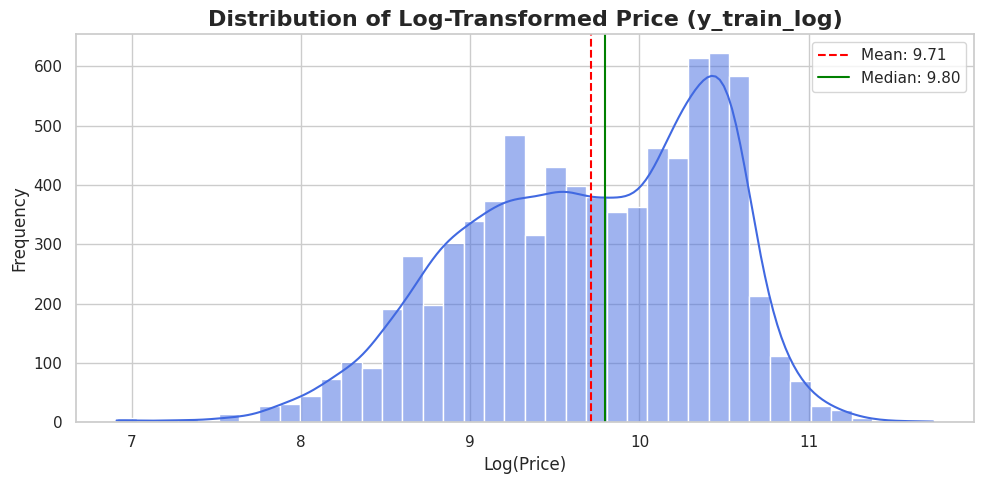

In [106]:
# 1. 정답지(Target) 분포 검증
# -> 꼬리가 길었던 가격 분포가 로그 변환 후 정규분포(종 모양)에 가까워졌는지 확인합니다.

plt.figure(figsize=(10, 5))
sns.histplot(df_eda['price_log'], bins=40, kde=True, color='royalblue')
plt.title("Distribution of Log-Transformed Price (y_train_log)", fontsize=16, fontweight='bold')
plt.xlabel("Log(Price)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# 평균과 중앙값 표시
plt.axvline(df_eda['price_log'].mean(), color='red', linestyle='--', label=f"Mean: {df_eda['price_log'].mean():.2f}")
plt.axvline(df_eda['price_log'].median(), color='green', linestyle='-', label=f"Median: {df_eda['price_log'].median():.2f}")

plt.legend()
plt.tight_layout()
plt.show()

# 멘트: "우측으로 치우쳤던 분포가 가운데로 예쁘게 모인 것을 확인할 수 있습니다."

## 2. StandardScaler 적용 결과 확인

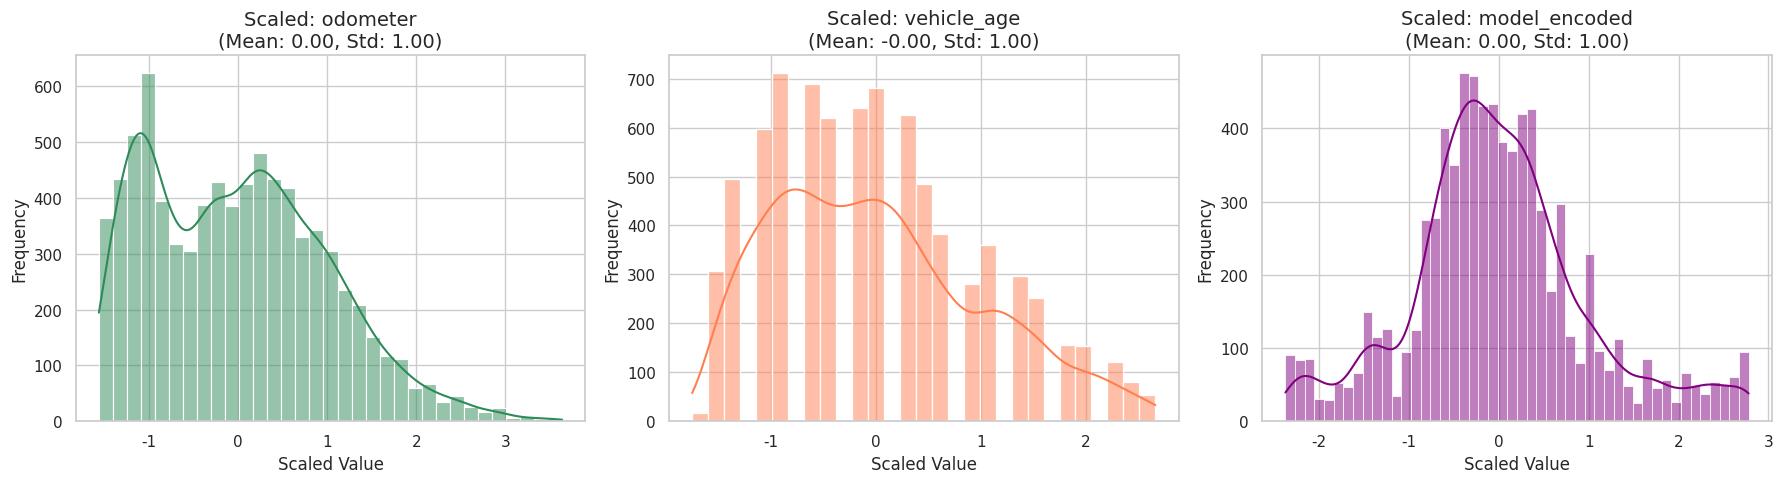

In [107]:
# 2. 스케일링된 수치형 변수 분포 검증
# -> 평균이 0, 표준편차가 1 근처로 잘 모였는지 확인합니다.

scaled_cols = ['odometer', 'vehicle_age', 'model_encoded']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['seagreen', 'coral', 'purple']

for i, col in enumerate(scaled_cols):
    sns.histplot(df_eda[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f"Scaled: {col}\n(Mean: {df_eda[col].mean():.2f}, Std: {df_eda[col].std():.2f})", fontsize=14)
    axes[i].set_xlabel("Scaled Value")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# 멘트: "세 변수 모두 평균 0을 기준으로 분포하고 있어, 모델이 특정 변수에만 가중치를 두는 문제를 방지했습니다."

## 3. Target Encoding의 위력 확인 - 회귀선 산점도

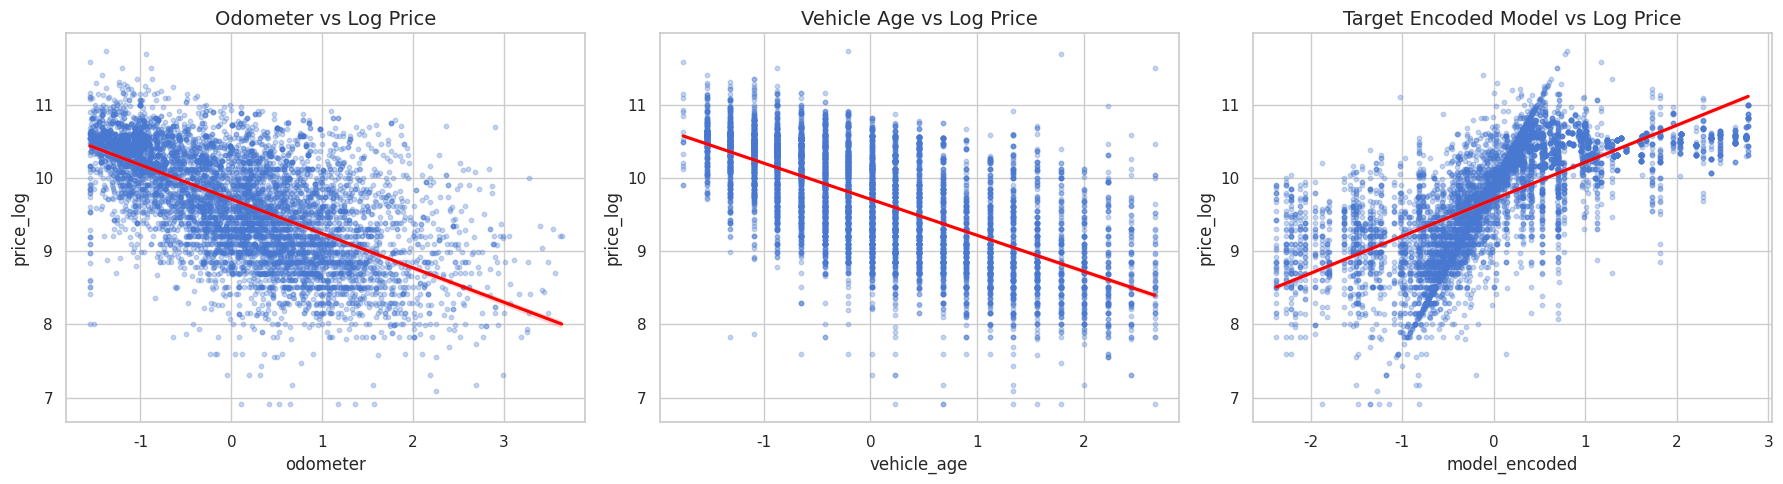

In [108]:
# 3. 주요 수치형/인코딩 변수와 가격(Log)의 관계
# 우리가 공들여 만든 'model_encoded'가 실제로 가격과 얼마나 강한 선형 관계를 가지는지 증명합니다.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3-1. 주행거리 vs 가격 (음의 상관관계 기대)
sns.regplot(data=df_eda, x='odometer', y='price_log', ax=axes[0],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[0].set_title("Odometer vs Log Price", fontsize=14)

# 3-2. 차량 나이 vs 가격 (음의 상관관계 기대)
sns.regplot(data=df_eda, x='vehicle_age', y='price_log', ax=axes[1],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[1].set_title("Vehicle Age vs Log Price", fontsize=14)

# 3-3. 모델 인코딩 값 vs 가격 (강한 양의 상관관계 기대!)
sns.regplot(data=df_eda, x='model_encoded', y='price_log', ax=axes[2],
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
axes[2].set_title("Target Encoded Model vs Log Price", fontsize=14)

plt.tight_layout()
plt.show()


## 4. 모델을 위한 핵심 상관관계 히트맵 - Top 15 피처

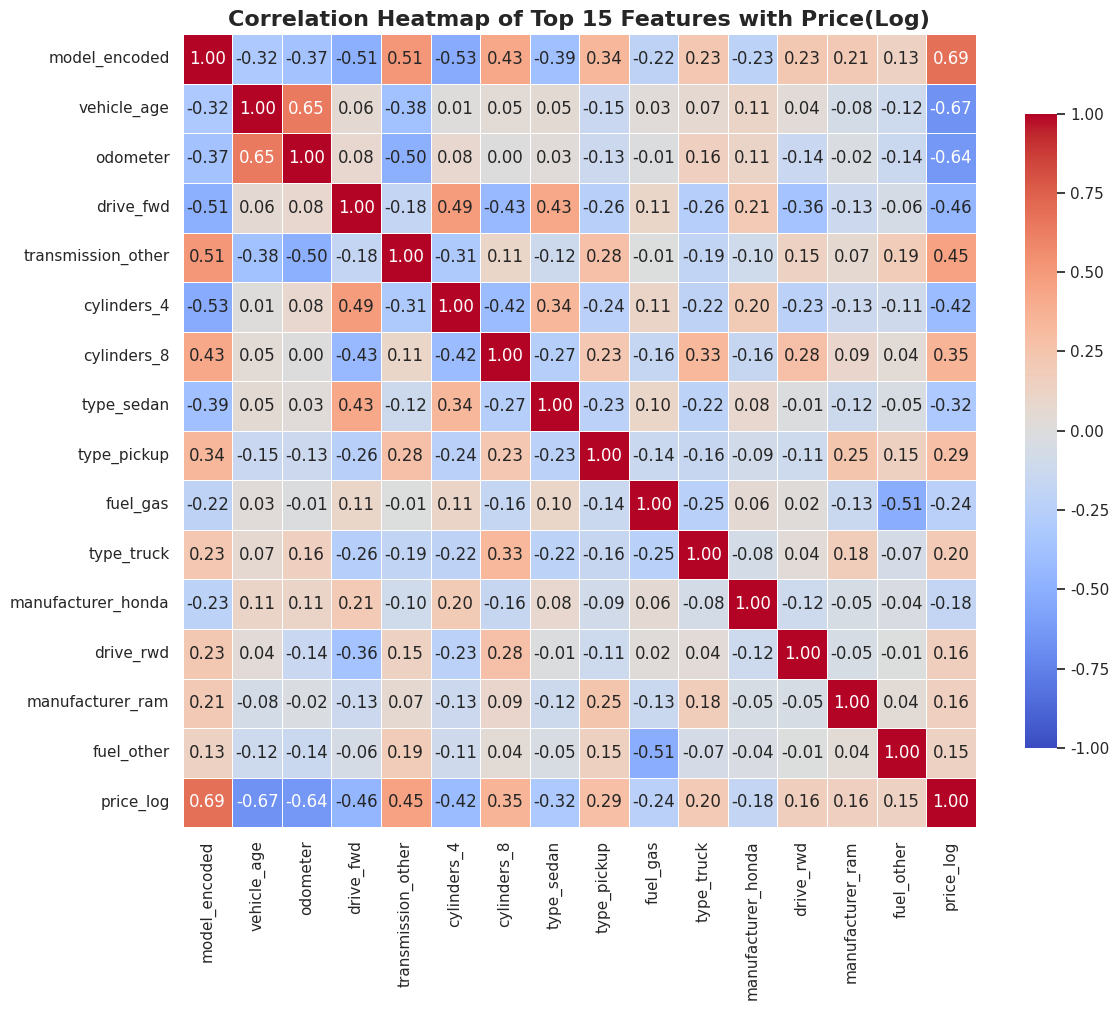

In [109]:
# 4. 타겟(price_log)과 가장 상관관계가 높은 Top 15 피처 추출 및 히트맵
# 원-핫 인코딩으로 피처가 30~40개로 늘어났으므로, 전부 그리면 안 보입니다. 가격과 가장 관련 깊은 애들만 뽑습니다.

# 타겟 변수와의 상관계수 계산 (절댓값 기준 내림차순)
correlations = df_eda.corr()['price_log'].abs().sort_values(ascending=False)

# 자기 자신(price_log)을 제외한 Top 15 피처 선정
top_15_features = correlations.index[1:16]

# Top 15 피처 + 타겟 변수로 상관관계 행렬 생성
top_corr_matrix = df_eda[top_15_features.tolist() + ['price_log']].corr()

plt.figure(figsize=(12, 10))
# 시각화 (YlGnBu 컬러맵 사용)
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title("Correlation Heatmap of Top 15 Features with Price(Log)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()